### Annotation

This project will try to explore the global landscape of the software development industry using data from the 2025 Stack Overflow Developer Survey. The primary purpose of the project is to analyze the relationships between a developer's experience, education level, adoption of AI tools, and their annual compensation. This will be achieved by performing exploratory data analysis and statistical analysis.

Project's team consisted of only one member: Eylkin Svyatoslav from group 252-1.

### Dataset Description

The subject area of the dataset is the technology and software development industry. The dataset is derived from the annual Stack Overflow Developer Survey, which captures responses from around 50k developers worldwide. The dataset contains numerous fields, including categorical fields (e.g., `EdLevel` for education, `AISelect` for AI usage stance, `ICorPM` for Individual Contributor vs. People Manager) and numerical fields (e.g., `ConvertedCompYearly` for USD salary, `WorkExp` for professional coding years, `YearsCode` for total coding years, `ToolsWork` for the number of distinct apps used at work, and `ToolsSide` for apps used on side projects). 

The dataset required some additional cleanup. There were missing values, especially in the compensation fields because many users, apparently, opt out of sharing their salary. There are extreme outliers in the salary and tools fields due to troll responses (e.g., 10,000 distinct tools used during a work) that must be filtered out using statistical methods.

I want to first focus on these columns:
1.  `ConvertedCompYearly` (Annual Compensation)
2.  `WorkExp` (Years of professional work experience)
3.  `YearsCode` (Total years coding)
4.  `ToolCountWork` (Distinct software applications used for the job)
5.  `ToolCountPersonal` (Distinct software applications used for side projects)
6.  `EdLevel` (Education)
7.  `AISelect` (Do you currently use AI tools...?)
8.  `ICorPM` (Individual contributor or People manager)

P.S.
When refering to salary in the code/text later I mean *Annual Compensation*.

In [64]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from scipy import stats

sns.set_theme(style="whitegrid")

In [65]:
df = pd.read_csv("./data/sof_survey_2025.csv")
df.head(2)

/tmp/ipykernel_280687/724876503.py:1: DtypeWarning: Columns (0: JobSatPoints_15_TEXT, 1: DatabaseHaveEntry, 2: DevEnvHaveEntry, 3: SOTagsHaveEntry, 4: SOTagsWant Entry, 5: OfficeStackWantEntry, 6: CommPlatformHaveEntr, 7: CommPlatformWantEntr, 8: SO_Actions_15_TEXT, 9: AIAgentOrchestration, 10: AIAgentObsWrite) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("./data/sof_survey_2025.csv")


,ResponseId,MainBranch,Age,EdLevel,Employment,EmploymentAddl,WorkExp,LearnCodeChoose,LearnCode,LearnCodeAI,...,AIAgentOrchestration,AIAgentOrchWrite,AIAgentObserveSecure,AIAgentObsWrite,AIAgentExternal,AIAgentExtWrite,AIHuman,AIOpen,ConvertedCompYearly,JobSat
0,1,I am a developer by profession,25-34 years old,"Master’s degree (M.A., M.S., M.Eng., MBA, etc.)",Employed,"Caring for dependents (children, elderly, etc.)",8.00,"Yes, I am not new to coding but am learning ne...",Online Courses or Certification (includes all ...,"Yes, I learned how to use AI-enabled tools for...",...,Vertex AI,NaN,NaN,NaN,ChatGPT,NaN,When I don’t trust AI’s answers,"Troubleshooting, profiling, debugging","61,256.00",10.00
1,2,I am a developer by profession,25-34 years old,"Associate degree (A.A., A.S., etc.)",Employed,NaN,2.00,"Yes, I am not new to coding but am learning ne...",Online Courses or Certification (includes all ...,"Yes, I learned how to use AI-enabled tools for...",...,NaN,NaN,NaN,NaN,NaN,NaN,When I don’t trust AI’s answers;When I want to...,All skills. AI is a flop.,"104,413.00",9.00


In [66]:
key_columns = [
    "ConvertedCompYearly",
    "WorkExp",
    "YearsCode",
    "EdLevel",
    "AISelect",
    "ICorPM",
    "ToolCountWork",
    "ToolCountPersonal",
]

display(df[key_columns].info())

<class 'pandas.DataFrame'>
RangeIndex: 49191 entries, 0 to 49190
Data columns (total 8 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   ConvertedCompYearly  23947 non-null  float64
 1   WorkExp              42893 non-null  float64
 2   YearsCode            43042 non-null  float64
 3   EdLevel              48149 non-null  str    
 4   AISelect             33720 non-null  str    
 5   ICorPM               33243 non-null  str    
 6   ToolCountWork        27611 non-null  float64
 7   ToolCountPersonal    25582 non-null  float64
dtypes: float64(5), str(3)
memory usage: 3.0 MB


None


### Data Cleanup and Transformation

We remove rows which do not contain critical information for our analysis.

In [67]:
df_clean = df.dropna(
    subset=[
        "ConvertedCompYearly",
        "YearsCode",
        "WorkExp",
        "ToolCountWork",
        "ToolCountPersonal",
    ]
).copy()

Now we remove outliers using the IQR Method from the lecture 7

In [68]:
cols_to_filter = ["ConvertedCompYearly", "ToolCountWork", "ToolCountPersonal"]

for col in cols_to_filter:
    q1 = df_clean[col].quantile(0.25)
    q3 = df_clean[col].quantile(0.75)
    iqr = q3 - q1

    l = max(0, q1 - 1.5 * iqr)
    u = q3 + 1.5 * iqr

    df_clean = df_clean[(df_clean[col] >= l) & (df_clean[col] <= u)]

In [69]:
print(
    f"Removed {(df.shape[0] - df_clean.shape[0])} rows containing missing values or extreme outliers."
)

Removed 34746 rows containing missing values or extreme outliers.


Now we add two new rows for the ease of later analysis:
- **`YearsCodeHobby`**: Equals to `YearsCode` - `WorkExp`. This gives us an estimate of how long a developer coded recreationally or academically before working professionally.
- **`EdLevel_Numeric`**: We want to convert categorical values of the `EdLevel` column to a numerical scale, so that we can you use this data in our analysis. The conversion rates: Primary School = 1, Secondary school = 2, Some college/university = 3, Associate degree = 4, Bachelor's degree = 5, Master's degree = 6, Professional Degree = 7.

In [70]:
df_clean["YearsCodeHobby"] = df_clean["YearsCode"] - df_clean["WorkExp"]
df_clean["YearsCodeHobby"] = df_clean["YearsCodeHobby"].apply(
    lambda x: x if x >= 0 else 0
)

In [71]:
ed_mapping = {
    "Primary/elementary school": 1,
    "Secondary school (e.g. American high school, German Realschule or Gymnasium, etc.)": 2,
    "Some college/university study without earning a degree": 3,
    "Associate degree (A.A., A.S., etc.)": 4,
    "Bachelor’s degree (B.A., B.S., B.Eng., etc.)": 5,
    "Master’s degree (M.A., M.S., M.Eng., MBA, etc.)": 6,
    "Professional degree (JD, MD, Ph.D, Ed.D, etc.)": 7,
}

df_clean["EdLevel_Numeric"] = df_clean["EdLevel"].map(ed_mapping)

In [72]:
display(
    df_clean[
        ["YearsCode", "WorkExp", "YearsCodeHobby", "EdLevel", "EdLevel_Numeric"]
    ].sample(5)
)

,YearsCode,WorkExp,YearsCodeHobby,EdLevel,EdLevel_Numeric
2590,25.00,17.00,8.00,"Bachelor’s degree (B.A., B.S., B.Eng., etc.)",5.00
41006,14.00,3.00,11.00,"Professional degree (JD, MD, Ph.D, Ed.D, etc.)",7.00
1569,13.00,13.00,0.00,Some college/university study without earning ...,3.00
3826,5.00,2.00,3.00,"Secondary school (e.g. American high school, G...",2.00
29697,5.00,3.00,2.00,Some college/university study without earning ...,3.00


### EDA
To understand the distributions and basic relations between the key numerical fields: `ConvertedCompYearly`, `ToolCountWork`, `YearsCodeHobby`, `WorkExp`, were created some visualizations using four different plot types:

- **Histogram**: for `ConvertedCompYearly` to observe the distribution of global developer salaries (revealing a heavy right-skew).
- **Boxplot**: for `ToolCountWork` to visualize the spread, median, and variance of the number of distinct tools used at work, which also serves to visually verify our IQR outlier cleanup.
- **Scatter plot**: `YearsCodeHobby` vs `ConvertedCompYearly` to explore the variance and density of pre-professional coding experience and its initial lack of clear linear correlation with current salary.
- **Line plot**: `ConvertedCompYearly` over `WorkExp` to track the average salary trajectory and its confidence interval as professional experience increases over time.

Additionally key indicators were calculated and analysed.

In [73]:
num_columns = [
    "ConvertedCompYearly",
    "WorkExp",
    "ToolCountWork",
    "ToolCountPersonal",
    "YearsCodeHobby",
    "YearsCode",
    "EdLevel_Numeric",
]

stats_df = df_clean[num_columns].describe().T

stats_df = stats_df[["mean", "50%", "std"]]
stats_df.rename(columns={"50%": "median"}, inplace=True)

pd.options.display.float_format = "{:,.2f}".format

display(stats_df)

,mean,median,std
ConvertedCompYearly,"78,920.19","70,440.00","55,897.89"
WorkExp,13.01,10.00,9.79
ToolCountWork,6.59,6.00,3.58
ToolCountPersonal,4.32,4.00,2.53
YearsCodeHobby,4.73,4.00,4.25
YearsCode,17.13,15.00,10.72
EdLevel_Numeric,4.96,5.00,1.25


In [74]:
print("\tEducation Level vs AI Usage")
ai_edu_pivot = df_clean[df_clean["EdLevel_Numeric"].isin([5.0, 6.0])].copy()
ai_edu_pivot["Education"] = ai_edu_pivot["EdLevel_Numeric"].map(
    {5.0: "Bachelor", 6.0: "Master"}
)

ai_edu_pivot = ai_edu_pivot[
    ai_edu_pivot["AISelect"].isin(
        ["Yes, I use AI tools daily", "No, and I don't plan to"]
    )
]
print(
    ai_edu_pivot.groupby(["Education", "AISelect"])["ConvertedCompYearly"]
    .median()
    .unstack()
)
print("\n")


print("\tMedian Salary: Tool Bloat vs Role")
df_clean["Tool_Bin"] = pd.cut(
    df_clean["ToolCountWork"],
    bins=[-1, 5, 10, 100],
    labels=["Low (0-5)", "Medium (6-10)", "High (>10)"],
)
print(
    df_clean.groupby(["ICorPM", "Tool_Bin"], observed=False)["ConvertedCompYearly"]
    .median()
    .unstack()
)
print("\n")

print("\tMedian Salary: Hobby Experience vs AI Usage")
df_clean["Hobby_Bin"] = pd.cut(
    df_clean["YearsCodeHobby"],
    bins=[-1, 3, 8, 100],
    labels=["Low (0-3 yrs)", "Medium (4-8 yrs)", "High (>8 yrs)"],
)
hobby_ai_pivot = df_clean[
    df_clean["AISelect"].isin(["Yes, I use AI tools daily", "No, and I don't plan to"])
]
print(
    hobby_ai_pivot.groupby(["Hobby_Bin", "AISelect"], observed=False)[
        "ConvertedCompYearly"
    ]
    .median()
    .unstack()
)

	Education Level vs AI Usage


AISelect   No, and I don't plan to  Yes, I use AI tools daily
Education                                                    
Bachelor                 83,200.00                  64,141.50
Master                   81,210.00                  75,410.00


	Median Salary: Tool Bloat vs Role
Tool_Bin                Low (0-5)  Medium (6-10)  High (>10)
ICorPM                                                      
Individual contributor  63,808.00      73,375.00   87,408.50
People manager          73,089.00      89,331.00   95,500.00


	Median Salary: Hobby Experience vs AI Usage
AISelect          No, and I don't plan to  Yes, I use AI tools daily
Hobby_Bin                                                           
Low (0-3 yrs)                   75,410.00                  58,007.00
Medium (4-8 yrs)                78,605.50                  70,386.00
High (>8 yrs)                   80,254.00                  87,011.00


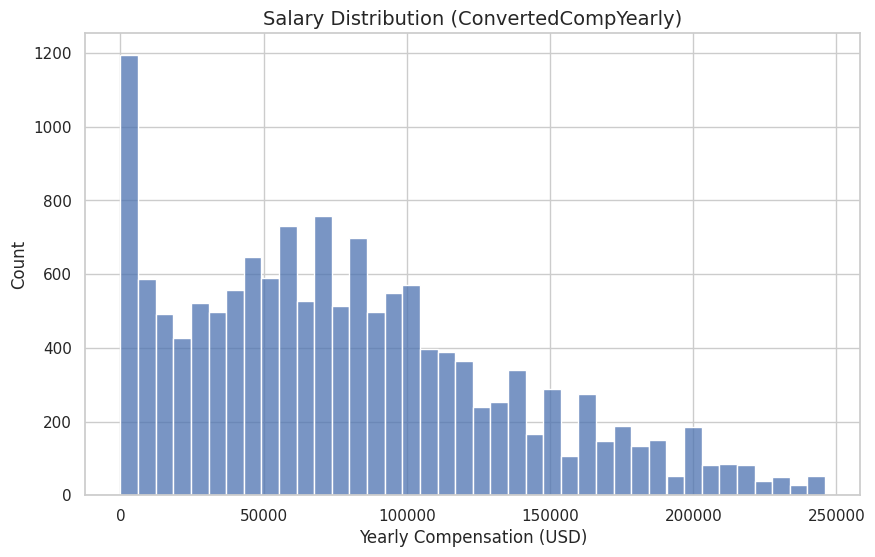

In [75]:
plt.figure(figsize=(10, 6))
sns.histplot(df_clean["ConvertedCompYearly"], bins=40)
plt.title("Salary Distribution (ConvertedCompYearly)", fontsize=14)
plt.xlabel("Yearly Compensation (USD)")
plt.ylabel("Count")
plt.show()

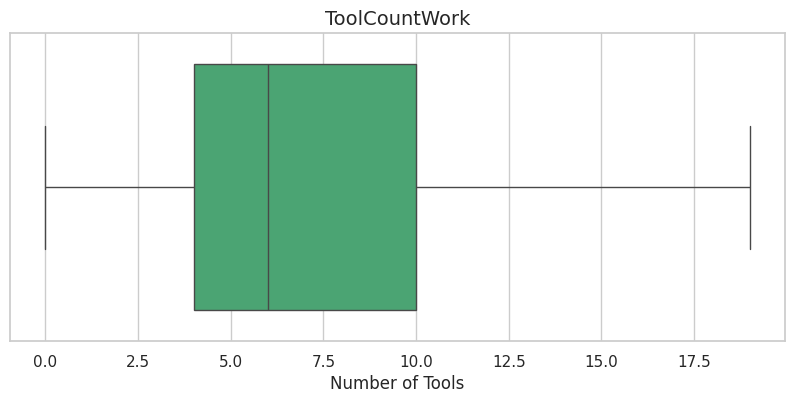

In [76]:
plt.figure(figsize=(10, 4))
sns.boxplot(x=df_clean["ToolCountWork"], color="mediumseagreen")
plt.title("ToolCountWork", fontsize=14)
plt.xlabel("Number of Tools")
plt.show()

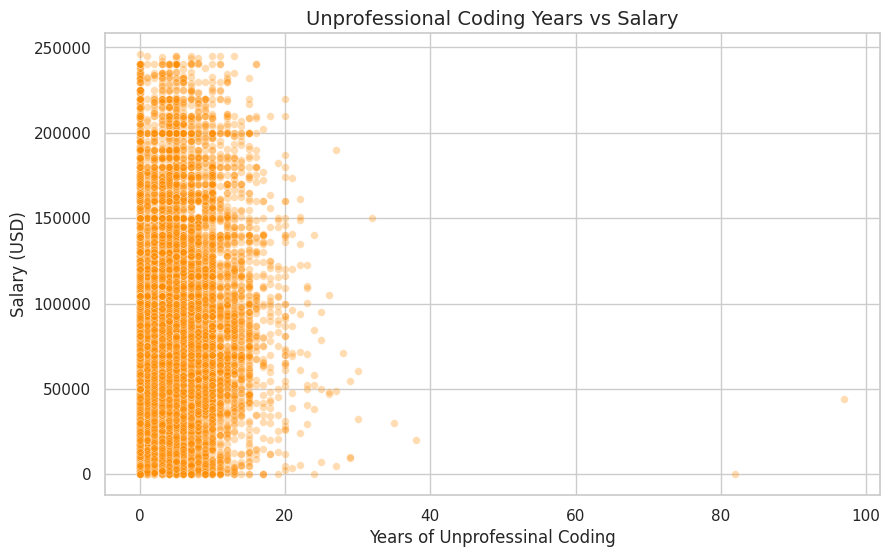

In [77]:
plt.figure(figsize=(10, 6))
sns.scatterplot(
    x="YearsCodeHobby",
    y="ConvertedCompYearly",
    data=df_clean,
    alpha=0.3,
    color="darkorange",
    s=30,
)
plt.title("Unprofessional Coding Years vs Salary", fontsize=14)
plt.xlabel("Years of Unprofessinal Coding")
plt.ylabel("Salary (USD)")
plt.show()

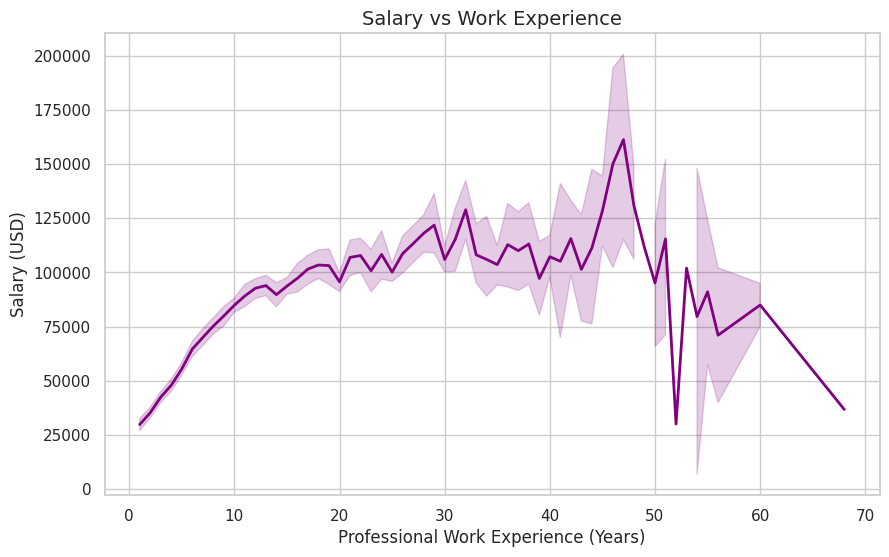

In [78]:
plt.figure(figsize=(10, 6))
sns.lineplot(
    x="WorkExp", y="ConvertedCompYearly", data=df_clean, color="purple", linewidth=2
)
plt.title("Salary vs Work Experience", fontsize=14)
plt.xlabel("Professional Work Experience (Years)")
plt.ylabel("Salary (USD)")
plt.show()

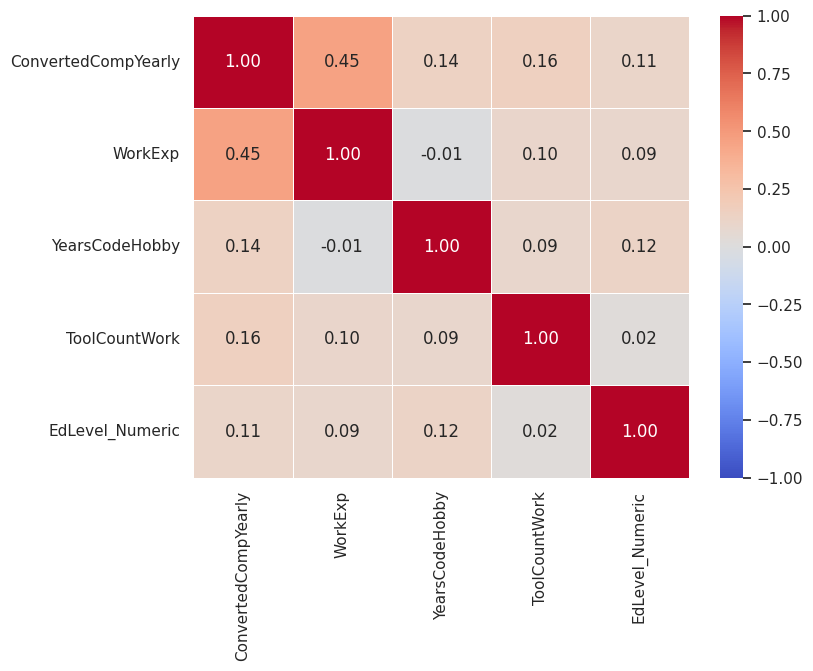

In [79]:
plt.figure(figsize=(8, 6))
corr_cols = [
    "ConvertedCompYearly",
    "WorkExp",
    "YearsCodeHobby",
    "ToolCountWork",
    "EdLevel_Numeric",
]
corr_matrix = df_clean[corr_cols].corr(method="spearman")

sns.heatmap(
    corr_matrix, annot=True, cmap="coolwarm", vmin=-1, vmax=1, fmt=".2f", linewidths=0.5
)
plt.show()

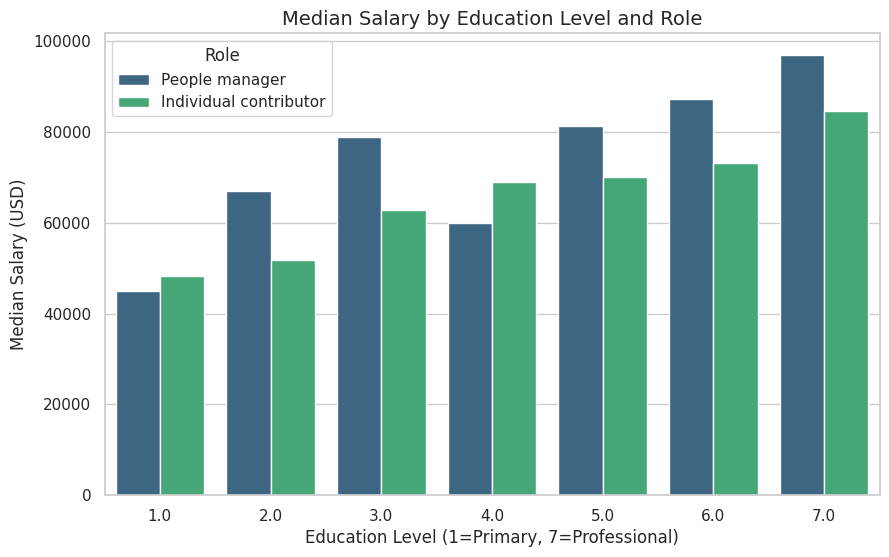

In [80]:
plt.figure(figsize=(10, 6))
role_df = df_clean.dropna(subset=["ICorPM", "EdLevel_Numeric"])

sns.barplot(
    x="EdLevel_Numeric",
    y="ConvertedCompYearly",
    hue="ICorPM",
    data=role_df,
    estimator=np.median,
    palette="viridis",
    errorbar=None,
)
plt.title("Median Salary by Education Level and Role", fontsize=14)
plt.xlabel("Education Level (1=Primary, 7=Professional)")
plt.ylabel("Median Salary (USD)")
plt.legend(title="Role")
plt.show()

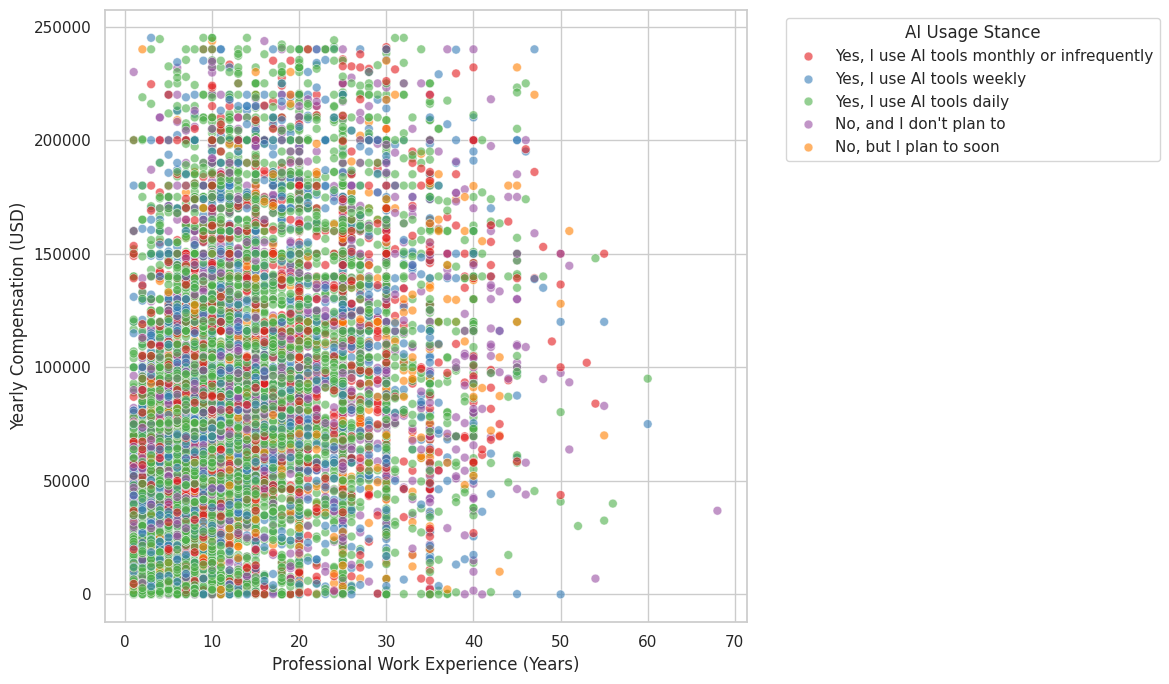

In [81]:
plt.figure(figsize=(12, 7))
sns.scatterplot(
    x="WorkExp",
    y="ConvertedCompYearly",
    hue="AISelect",
    data=df_clean,
    alpha=0.6,
    palette="Set1",
    s=40,
)
plt.xlabel("Professional Work Experience (Years)")
plt.ylabel("Yearly Compensation (USD)")
plt.legend(title="AI Usage Stance", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.show()

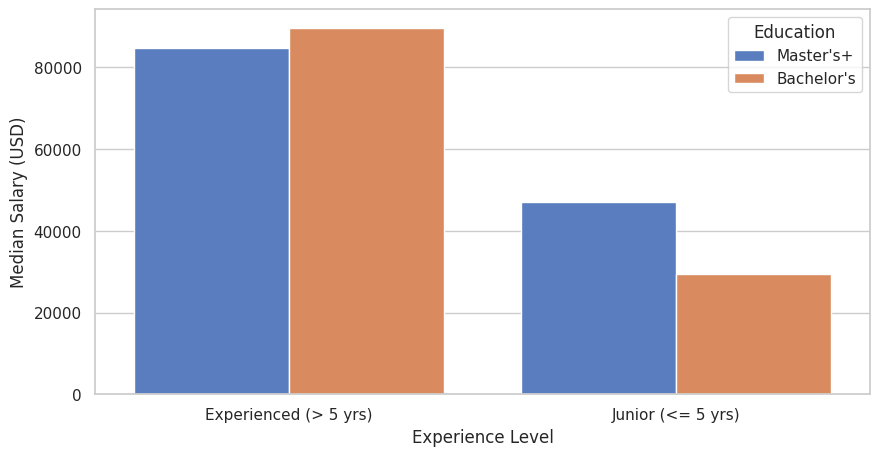

In [82]:
plt.figure(figsize=(10, 5))
plot_df = df_clean[df_clean["EdLevel_Numeric"].isin([5.0, 6.0, 7.0])].copy()
plot_df["Education"] = plot_df["EdLevel_Numeric"].map(
    {5.0: "Bachelor's", 6.0: "Master's+", 7.0: "Master's+"}
)
plot_df["Exp_Category"] = plot_df["WorkExp"].apply(
    lambda x: "Junior (<= 5 yrs)" if x <= 5 else "Experienced (> 5 yrs)"
)

sns.barplot(
    x="Exp_Category",
    y="ConvertedCompYearly",
    hue="Education",
    data=plot_df,
    estimator=np.median,
    palette="muted",
    errorbar=None,
)
plt.xlabel("Experience Level")
plt.ylabel("Median Salary (USD)")
plt.show()

Now that we have a broad overview of the data, I will test two hypotheses.

### Hypothesis 1

A common assumption is that AI makes developers more valuable. However, I hypothesize the opposite: **Refusing to use AI tools is currently associated with a statistically significant salary boost**. Furthermore, I hypothesize that this increase exists for **both** Individual Contributors and People Managers.

In [83]:
ai_users = df_clean[df_clean["AISelect"] == "Yes, I use AI tools daily"]
non_ai_users = df_clean[df_clean["AISelect"] == "No, and I don't plan to"]

ic_ai = ai_users[ai_users["ICorPM"] == "Individual contributor"][
    "ConvertedCompYearly"
].dropna()
ic_non = non_ai_users[non_ai_users["ICorPM"] == "Individual contributor"][
    "ConvertedCompYearly"
].dropna()

print("\tIndividual Contributors")
print(
    f"Median Salary | Non-User: ${ic_non.median():,.0f} vs AI Daily: ${ic_ai.median():,.0f}"
)

stat_ic, p_ic = stats.mannwhitneyu(ic_non, ic_ai, alternative="greater")
print(f"p-value: {p_ic:.4e}")
if p_ic < 0.05:
    print(
        "Result: SIGNIFICANT. Non-using ICs earn a statistically significant premium over AI-using ICs.\n"
    )
else:
    print("Result: NOT SIGNIFICANT.\n")

	Individual Contributors
Median Salary | Non-User: $78,006 vs AI Daily: $67,190
p-value: 1.0887e-18
Result: SIGNIFICANT. Non-using ICs earn a statistically significant premium over AI-using ICs.



In [84]:
pm_ai = ai_users[ai_users["ICorPM"] == "People manager"]["ConvertedCompYearly"].dropna()
pm_non = non_ai_users[non_ai_users["ICorPM"] == "People manager"][
    "ConvertedCompYearly"
].dropna()

print("\tPeople Managers")
print(
    f"Median Salary | Non-User: ${pm_non.median():,.0f} vs AI Daily: ${pm_ai.median():,.0f}"
)
stat_pm, p_pm = stats.mannwhitneyu(pm_non, pm_ai, alternative="greater")
print(f"p-value: {p_pm:.4e}")
if p_pm < 0.05:
    print(
        "Result: SIGNIFICANT. Non-using Managers earn a statistically significant premium over AI-using Managers.\n"
    )
else:
    print("Result: NOT SIGNIFICANT.\n")

	People Managers
Median Salary | Non-User: $89,183 vs AI Daily: $75,744
p-value: 1.2486e-03
Result: SIGNIFICANT. Non-using Managers earn a statistically significant premium over AI-using Managers.



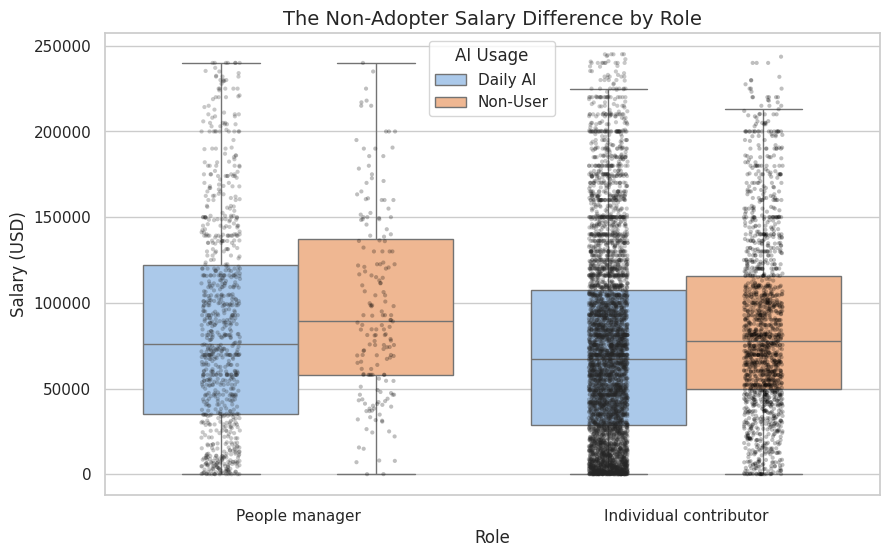

In [85]:
plot_h1 = df_clean[
    (
        df_clean["AISelect"].isin(
            ["Yes, I use AI tools daily", "No, and I don't plan to"]
        )
    )
    & (df_clean["ICorPM"].isin(["Individual contributor", "People manager"]))
].copy()
plot_h1["AI Usage"] = plot_h1["AISelect"].map(
    {"Yes, I use AI tools daily": "Daily AI", "No, and I don't plan to": "Non-User"}
)

fig, ax = plt.subplots(figsize=(10, 6))
sns.boxplot(
    data=plot_h1,
    x="ICorPM",
    y="ConvertedCompYearly",
    hue="AI Usage",
    palette="pastel",
    showfliers=False,
    ax=ax,
)
sns.stripplot(
    data=plot_h1,
    x="ICorPM",
    y="ConvertedCompYearly",
    hue="AI Usage",
    dodge=True,
    palette="dark:black",
    alpha=0.25,
    jitter=True,
    size=3,
    ax=ax,
)

handles, labels = ax.get_legend_handles_labels()
ax.legend(handles[:2], labels[:2], title="AI Usage")
ax.set_title("The Non-Adopter Salary Difference by Role", fontsize=14)
ax.set_ylabel("Salary (USD)")
ax.set_xlabel("Role")
plt.show()

The data proved the opposite of the initial hypothesis. **Refusing to use AI tools provides a statistically significant salary premium** for both Individual Contributors (p < 0.0001) and People Managers (p = 0.0012). This might indicate that in 2025, non-adopters represent highly tenured senior developers or professionals working in highly regulated, lucrative industries (like finance or defense) where AI is restricted. AI usage currently correlates with lower-paying or junior-heavy environments.

### Hypothesis 2

I hypothesize that for developers with a standard foundational background (<= 8 years of hobby coding), daily AI usage is associated with lower salaries. However, for "hardcore" hobbyists (> 8 years of non-professional coding), AI acts as an "accelerator," providing a statistically significant salary increase over those who refuse to use AI.

In [86]:
ai_df = df_clean[
    df_clean["AISelect"].isin(["Yes, I use AI tools daily", "No, and I don't plan to"])
].copy()

std_hobby = ai_df[ai_df["YearsCodeHobby"] <= 8]
ai_std = std_hobby[std_hobby["AISelect"] == "Yes, I use AI tools daily"][
    "ConvertedCompYearly"
].dropna()
non_std = std_hobby[std_hobby["AISelect"] == "No, and I don't plan to"][
    "ConvertedCompYearly"
].dropna()

print("\tStandard Hobbyists (<= 8 Years Hobby Coding)")
print(
    f"Median Salary | AI Daily: ${ai_std.median():,.0f} vs Non-User: ${non_std.median():,.0f}"
)

stat_std, p_std = stats.mannwhitneyu(non_std, ai_std, alternative="greater")
print(f"p-value: {p_std:.4e}")
if p_std < 0.05:
    print("Result: SIGNIFICANT. Non-users earn more.\n")
else:
    print("Result: NOT SIGNIFICANT.\n")

	Standard Hobbyists (<= 8 Years Hobby Coding)
Median Salary | AI Daily: $64,000 vs Non-User: $76,825
p-value: 2.1193e-21
Result: SIGNIFICANT. Non-users earn more.



In [87]:
hdc_hobby = ai_df[ai_df["YearsCodeHobby"] > 8]
ai_hard = hdc_hobby[hdc_hobby["AISelect"] == "Yes, I use AI tools daily"][
    "ConvertedCompYearly"
].dropna()
non_hard = hdc_hobby[hdc_hobby["AISelect"] == "No, and I don't plan to"][
    "ConvertedCompYearly"
].dropna()

print("\tHardcore Hobbyists (> 8 Years Hobby Coding)")
print(
    f"Median Salary | AI Daily: ${ai_hard.median():,.0f} vs Non-User: ${non_hard.median():,.0f}"
)
stat_hard, p_hard = stats.mannwhitneyu(ai_hard, non_hard, alternative="greater")
print(f"p-value: {p_hard:.4e}")
if p_hard < 0.05:
    print("Result: SIGNIFICANT. AI users earn more.\n")
else:
    print("Result: NOT SIGNIFICANT.\n")

	Hardcore Hobbyists (> 8 Years Hobby Coding)
Median Salary | AI Daily: $87,011 vs Non-User: $80,254
p-value: 1.4081e-02
Result: SIGNIFICANT. AI users earn more.



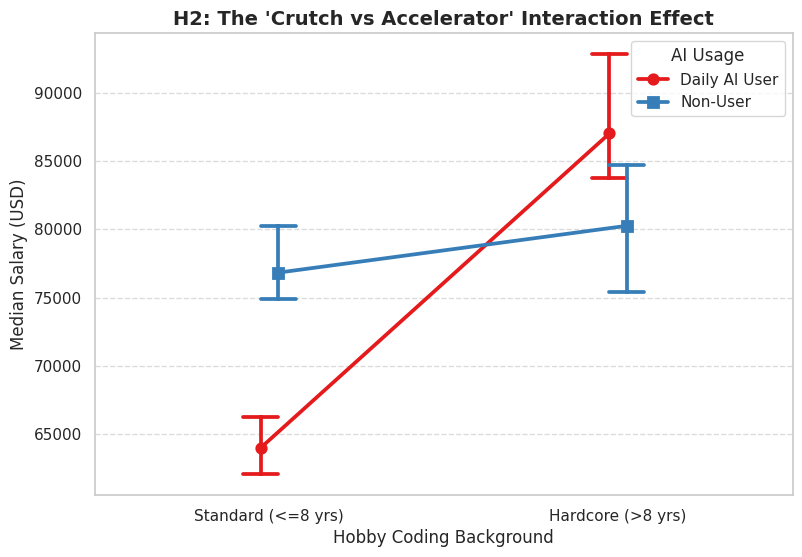

In [88]:
plt.figure(figsize=(9, 6))

plot_h2 = ai_df.copy()
plot_h2["Hobby_Background"] = plot_h2["YearsCodeHobby"].apply(
    lambda x: "Hardcore (>8 yrs)" if x > 8 else "Standard (<=8 yrs)"
)
plot_h2["AI_Usage"] = plot_h2["AISelect"].map(
    {
        "Yes, I use AI tools daily": "Daily AI User",
        "No, and I don't plan to": "Non-User",
    }
)

sns.pointplot(
    data=plot_h2,
    x="Hobby_Background",
    y="ConvertedCompYearly",
    hue="AI_Usage",
    estimator=np.median,
    errorbar=("ci", 95),
    capsize=0.1,
    palette="Set1",
    dodge=True,
    markers=["o", "s"],
)

plt.title(
    "H2: The 'Crutch vs Accelerator' Interaction Effect", fontsize=14, fontweight="bold"
)
plt.xlabel("Hobby Coding Background")
plt.ylabel("Median Salary (USD)")
plt.legend(title="AI Usage")
plt.grid(axis="y", linestyle="--", alpha=0.7)
plt.show()

The data showed that:  
- For developers with a standard background (<= 8 years of pre-professional hobby coding), daily AI usage is associated with significantly *lower* pay (p < 0.0001), suggesting it may act as a "crutch" for less experienced developers.
- However, for "hardcore" hobbyists (> 8 years), the trend reverses. Daily AI users earn much more than non-users (p = 0.014). 
The key takeway can be that AI tools act as an *accelerator* that boosts salary only if the developer already possesses deep, foundational coding knowledge. Without that deep foundation, AI usage correlates with lower compensation.

### Discussion

**What I did and why:**
- Performed data cleanup by dropping missing values in critical columns, and applying the IQR method to remove extreme outliers in salary and tool counts. Verified cleanliness via dtype checks.
- Computed descriptive stats (mean, median, std) for 4+ numerical fields and created multiple plot types (histograms, boxplots, line plots, scatterplots) for initial exploration of distributions (revealing a heavy right-skew in compensation).
- Added 2 transformed columns: `YearsCodeHobby` (subtracting professional experience from total coding years) and `EdLevel_Numeric` (ordinal mapping of education levels) to enable categorical grouping and quantitative hypothesis testing.
- For detailed overview: used comparisons with hue, side-by-side subplot visualizations, and a Spearman correlation heatmap to reveal interactions (e.g., work vs. personal tool usage, correlation between experience and pay).
- Tested 2 hypotheses:
  - **H1:** The "Non-Adopter" Premium by Role. Tested if refusing to use AI tools correlates with higher pay across different roles. **Result:** Statistically significant (p < 0.05). Non-users currently earn a salary premium in both Individual Contributor and People Manager roles.
  - **H2:** The "Crutch vs. Accelerator" Effect. Tested how daily AI usage interacts with pre-professional hobby coding. **Result:** Statistically significant (p < 0.05). AI correlates with lower pay for standard hobbyists (<= 8 years) but acts as a positive salary multiplier for "hardcore" hobbyists (> 8 years), confirming the interaction effect.
- All plots were created using Matplotlib/Seaborn.